      width/height < 0.6: #7731 #1
0.6 <= width/height < 0.7: #22966 #2
0.7 <= width/height < 0.8: #46997 #3
0.8 <= width/height < 0.9: #45458 #4
0.9 <= width/height < 1.0: #16786 #5
1.0 <= width/height      : #18979 #6


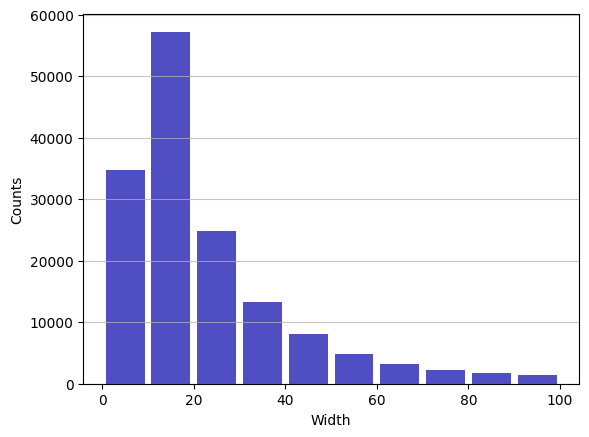

In [8]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

if __name__ == '__main__':
  anno_file = 'annotation.txt'
  with open(anno_file, 'r') as fp:
    lines = fp.readlines()
  # Enter your code here (25%)
  # You might use the following to access each line
  annotation_list = []
  list_1=[]
  invalid_list=[]
  bbox_list=[]
  widths=[]
  heights=[]
  wdivh1=0
  wdivh2=0
  wdivh3=0
  wdivh4=0
  wdivh5=0
  wdivh6=0
  for line in lines:
    annotation = line.strip().split(' ')
    annotation = np.array(annotation[1:])
    annotation =[int(x) for x in annotation]
    annotation_list.append(annotation)
    
  for list1 in annotation_list:
    length = int(len(list1)/4)
    list1 = np.reshape(list1, (length, -1))
    list_1.append(list1)
        
    for list2 in list1:
        bbox = list2
        width = bbox[2] - bbox[0] + 1
        height = bbox[3]-bbox[1]+1

        if ((bbox[0]<0) or (bbox[1]<0) or (bbox[2]<bbox[0]) or (bbox[3]<bbox[1])):
            invalid_list.append(bbox)
        else:
            bbox_list.append(bbox)
            widths.append(width)
            heights.append(height)
            
  for width, height in zip(widths, heights):
    ratio = width / height
    if ratio < 0.6:
      wdivh1 += 1
    elif 0.6 <= ratio < 0.7:
      wdivh2 += 1
    elif 0.7 <= ratio < 0.8:
      wdivh3 += 1
    elif 0.8 <= ratio < 0.9:
      wdivh4 += 1
    elif 0.9 <= ratio < 1.0:
      wdivh5 += 1
    else:
      wdivh6 += 1

  print("      width/height < 0.6: #" + str(wdivh1) +" #1")
  print("0.6 <= width/height < 0.7: #" + str(wdivh2) +" #2")
  print("0.7 <= width/height < 0.8: #" + str(wdivh3) +" #3")
  print("0.8 <= width/height < 0.9: #" + str(wdivh4) +" #4")
  print("0.9 <= width/height < 1.0: #" + str(wdivh5) +" #5")
  print("1.0 <= width/height      : #" + str(wdivh6) +" #6")
  
  bin_range = range(0, 101, 10)
  n, bins, patches = plt.hist(widths, bins=bin_range, color='#0504aa', alpha=0.7, rwidth=0.85)
  plt.grid(axis='y', alpha=0.75)
  plt.xlabel('Width')
  plt.ylabel('Counts')
  plt.show()

In [9]:
len(invalid_list)

507

In [ ]:
# Step 2b.5: In Step 2b.1, we only consider valid bounding boxes. How many bounding boxes are invalid? Modify the above code to find the answer. (5%)
# Write down your answer here.
507 code中有用if去判斷是不是invalid，然後儲存bounding box的invalid_list，用len(bbox_invalid_list)可以知道數量。